<a href="https://colab.research.google.com/github/Thejuskuku/Hybrid_FISTA-RT/blob/main/HybridFISTA-RT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.fft
from tensorflow.keras.datasets import mnist

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True

def tsvd_and_compare_sizes(A, R):
    n1, n2, n3 = A.shape
    total_original = A.numel()

    print("====================================")
    print(" BEFORE t-SVD")
    print("====================================")
    print(f" Original Tensor (X) : {n1} x {n2} x {n3}")
    print(f" Total Elements      : {total_original:,}")
    print("====================================\n")

    # 1. Fourier Domain
    A_f = torch.fft.fft(A, dim=2)

    U_f = torch.zeros((n1, R, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((R, R, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, R, n3), dtype=torch.complex64, device=device)

    # 2. Slice-wise SVD & Truncation
    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)
        U_f[:, :, i] = U[:, :R]
        S_f[:, :, i] = torch.diag(S[:R])
        V_f[:, :, i] = Vh[:R, :].conj().T

    # 3. Return to Spatial Domain
    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    total_reduced = U_t.numel() + S_t.numel() + V_t.numel()
    elements_saved = total_original - total_reduced
    reduction_percentage = (elements_saved / total_original) * 100
    compression_ratio = total_original / total_reduced

    print("====================================")
    print(f" AFTER t-SVD (Rank R={R})")
    print("====================================")
    print(f" Left Tensor (U)     : {U_t.shape[0]} x {U_t.shape[1]} x {U_t.shape[2]}")
    print(f" Core Tensor (S)     : {S_t.shape[0]} x {S_t.shape[1]} x {S_t.shape[2]}")
    print(f" Right Tensor (V)    : {V_t.shape[0]} x {V_t.shape[1]} x {V_t.shape[2]}")
    print(f" Total Elements      : {total_reduced:,}")
    print("====================================\n")

    print("====================================")
    print(" REDUCTION SUMMARY")
    print("====================================")
    print(f" Elements Saved      : {elements_saved:,}")
    print(f" Data Reduced By     : {reduction_percentage:.2f}%")
    print(f" Compression Ratio   : {compression_ratio:.2f}x smaller")
    print("====================================")

    return U_t, S_t, V_t


# DATA PREPARATION & EXECUTION

print("Loading MNIST dataset...")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T,
        device=device
    )

print("Running SVD dimension check...\n")
U_reduced, S_reduced, V_reduced = tsvd_and_compare_sizes(tensor_mnist, R=30)

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Running SVD dimension check...

 BEFORE t-SVD
 Original Tensor (X) : 784 x 5000 x 10
 Total Elements      : 39,200,000

 AFTER t-SVD (Rank R=30)
 Left Tensor (U)     : 784 x 30 x 10
 Core Tensor (S)     : 30 x 30 x 10
 Right Tensor (V)    : 5000 x 30 x 10
 Total Elements      : 1,744,200

 REDUCTION SUMMARY
 Elements Saved      : 37,455,800
 Data Reduced By     : 95.55%
 Compression Ratio   : 22.47x smaller


**PSNR COMPARISON**

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting Method 1: Standard tSVD | Rank=30]

[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
Paper Baseline Iter   1 Complete
Paper Baseline Iter  20 Complete
Paper Baseline Iter  40 Complete
Paper Baseline Iter  60 Complete
Paper Baseline Iter  80 Complete
Paper Baseline Iter 100 Complete

[Starting Method 3: Hybrid FISTA + Tracking | Rank=30, alpha=0.2]
Hybrid Iter   1 | Fit = 0.6182
Hybrid Iter  20 | Fit = 0.7343
Hybrid Iter  40 | Fit = 0.7604
Hybrid Iter  60 | Fit = 0.7711
Hybrid Iter  80 | Fit = 0.7769
Hybrid Iter 100 | Fit = 0.7806

FINAL PSNR COMPARISON (Rank = 30)
Method 1: Standard tSVD        : 17.897 dB
Method 2: Paper (NTD-1SVD)     : 21.446 dB
Method 3: Hybrid FISTA         : 22.922 dB


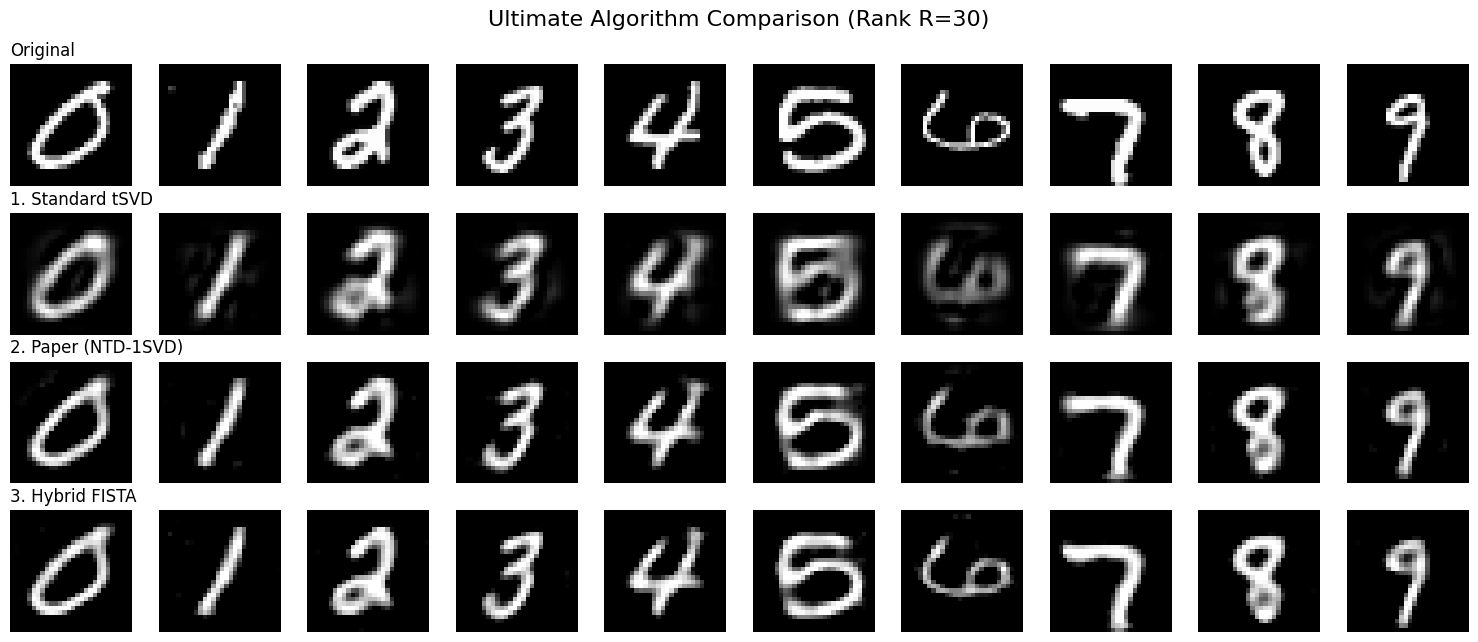

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD (Direct Linear Baseline)
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)

    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]

    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"\n[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]

        X_k = tprod(tprod(U_r, S_r), tran(V_r))

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Paper Baseline Iter {iter_idx:3d} Complete")

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"\n[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(X - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Hybrid Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. UTILITIES
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_four_way_comparison(original, recon_tsvd, recon_paper, recon_hybrid, sample_idx=420):
    original = original.cpu().numpy()
    recon_tsvd = recon_tsvd.cpu().numpy()
    recon_paper = recon_paper.cpu().numpy()
    recon_hybrid = recon_hybrid.cpu().numpy()

    fig, axes = plt.subplots(4, 10, figsize=(15, 6.5))
    fig.suptitle('Ultimate Algorithm Comparison (Rank R=30)', fontsize=16)

    for digit in range(10):
        orig = original[:, sample_idx, digit].reshape(28, 28)
        tsvd_img = recon_tsvd[:, sample_idx, digit].reshape(28, 28)
        paper_img = recon_paper[:, sample_idx, digit].reshape(28, 28)
        hybrid_img = recon_hybrid[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0: axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(tsvd_img, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0: axes[1, digit].set_title("1. Standard tSVD", loc='left')

        axes[2, digit].imshow(paper_img, cmap='gray', vmin=0, vmax=1)
        axes[2, digit].axis('off')
        if digit == 0: axes[2, digit].set_title("2. Paper (NTD-1SVD)", loc='left')

        axes[3, digit].imshow(hybrid_img, cmap='gray', vmin=0, vmax=1)
        axes[3, digit].axis('off')
        if digit == 0: axes[3, digit].set_title("3. Hybrid FISTA", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. EXECUTION & HEAD-TO-HEAD COMPARISON
# ==========================================
TARGET_RANK = 30

# Method 1
P_recon_tsvd = Standard_tSVD(tensor_mnist, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
psnr_tsvd = calculate_psnr(tensor_mnist, final_tsvd)

# Method 2
P_recon_paper = NTD_1SVD_Paper(tensor_mnist, R=TARGET_RANK, maxiters=100)
final_paper = torch.clamp(P_recon_paper, 0, 1)
psnr_paper = calculate_psnr(tensor_mnist, final_paper)

# Method 3
P_recon_hybrid = NTD_tSVD_FISTA_Optimized(
    tensor_mnist, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=100
)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
psnr_hybrid = calculate_psnr(tensor_mnist, final_hybrid)


# ==========================================
# 6. RESULTS
# ==========================================
print("\n=======================================================")
print(f"FINAL PSNR COMPARISON (Rank = {TARGET_RANK})")
print("=======================================================")
print(f"Method 1: Standard tSVD        : {psnr_tsvd:.3f} dB")
print(f"Method 2: Paper (NTD-1SVD)     : {psnr_paper:.3f} dB")
print(f"Method 3: Hybrid FISTA         : {psnr_hybrid:.3f} dB")
print("=======================================================")

# Visualize
plot_four_way_comparison(tensor_mnist, final_tsvd, final_paper, final_hybrid, sample_idx=420)

**RELATIVE ERROR**

In [ ]:
import torch
import torch.fft
import math
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30, verbose=True):
    if verbose: print(f"  -> Running Standard tSVD...")
    U, S, V = tsvd(M)

    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]

    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100, verbose=True):
    if verbose: print(f"  -> Running Paper Baseline (NTD-1SVD)...")
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]

        X_k = tprod(tprod(U_r, S_r), tran(V_r))
    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5, verbose=True):
    if verbose: print(f"  -> Running Hybrid FISTA...")
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS
# ==========================================
def calculate_relative_error(original, reconstructed):
    """
    Calculates: || M - max(0, X) ||_F / || M ||_F
    This matches the specific relative error metric used in the paper.
    """
    reconstructed_pos = torch.clamp(reconstructed, min=0)
    residual_norm = torch.norm(original - reconstructed_pos)
    original_norm = torch.norm(original)
    return (residual_norm / original_norm).item()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. EXECUTION LOOP
# ==========================================
ranks_to_test = [15, 20, 30]

# Dictionaries to hold the results
results_tsvd = []
results_paper = []
results_hybrid = []

print("\n[Starting Experiment Loop]")
for R in ranks_to_test:
    print(f"\nEvaluating Rank = {R}...")

    # 1. Standard tSVD
    P_tsvd = Standard_tSVD(tensor_mnist, R=R, verbose=True)
    err_tsvd = calculate_relative_error(tensor_mnist, P_tsvd)
    results_tsvd.append(err_tsvd)

    # 2. NTD-1SVD (Paper Baseline)
    P_paper = NTD_1SVD_Paper(tensor_mnist, R=R, maxiters=100, verbose=True)
    err_paper = calculate_relative_error(tensor_mnist, P_paper)
    results_paper.append(err_paper)

    # 3. Hybrid FISTA + Tracking
    P_hybrid = NTD_tSVD_FISTA_Optimized(tensor_mnist, R=R, alpha=0.2, alpha_decay=0.90, maxiters=100, verbose=True)
    err_hybrid = calculate_relative_error(tensor_mnist, P_hybrid)
    results_hybrid.append(err_hybrid)


# ==========================================
# 6. PRINT PAPER-STYLE TABLE
# ==========================================
print("\n")
print("=" * 60)
print(f"TABLE: Relative errors on MNIST dataset under different R")
print("=" * 60)
print(f"{'Algorithms':<20} | {'R = 15':<10} | {'R = 20':<10} | {'R = 30':<10}")
print("-" * 60)
print(f"{'tSVD':<20} | {results_tsvd[0]:.2e}   | {results_tsvd[1]:.2e}   | {results_tsvd[2]:.2e}")
print(f"{'NTD-1SVD (Paper)':<20} | {results_paper[0]:.2e}   | {results_paper[1]:.2e}   | {results_paper[2]:.2e}")
print(f"{'Hybrid FISTA (Yours)':<20} | {results_hybrid[0]:.2e}   | {results_hybrid[1]:.2e}   | {results_hybrid[2]:.2e}")
print("=" * 60)

Using device: cuda

[Loading MNIST dataset...]
Dataset shape: torch.Size([784, 5000, 10])

[Starting Experiment Loop]

Evaluating Rank = 15...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...

Evaluating Rank = 20...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...

Evaluating Rank = 30...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...


TABLE: Relative errors on MNIST dataset under different R
Algorithms           | R = 15     | R = 20     | R = 30    
------------------------------------------------------------
tSVD                 | 4.80e-01   | 4.42e-01   | 3.82e-01
NTD-1SVD (Paper)     | 4.05e-01   | 3.41e-01   | 2.58e-01
Hybrid FISTA (Yours) | 3.86e-01   | 3.08e-01   | 2.19e-01


In [ ]:
import os
import torch
import torch.fft
import math
import numpy as np
import scipy.io
from PIL import Image

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30, verbose=True):
    if verbose: print(f"  -> Running Standard tSVD...")
    U, S, V = tsvd(M)

    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]

    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100, verbose=True):
    if verbose: print(f"  -> Running Paper Baseline (NTD-1SVD)...")
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]

        X_k = tprod(tprod(U_r, S_r), tran(V_r))
    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5, verbose=True):
    if verbose: print(f"  -> Running Hybrid FISTA...")
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS
# ==========================================
def calculate_relative_error(original, reconstructed):
    """
    Calculates: || M - max(0, X) ||_F / || M ||_F
    This matches the specific relative error metric used in the paper.
    """
    reconstructed_pos = torch.clamp(reconstructed, min=0)
    residual_norm = torch.norm(original - reconstructed_pos)
    original_norm = torch.norm(original)
    return (residual_norm / original_norm).item()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
def get_coil20_tensor(device, path="coil20"):
    print("\n[Preparing COIL-20 dataset...]")
    if os.path.exists(path) and len(os.listdir(path)) > 0:
        images = []
        for file in sorted(os.listdir(path)):
            if file.endswith((".png", ".jpg", ".jpeg")):
                img = Image.open(os.path.join(path, file)).convert("L")
                images.append(np.array(img))
        if len(images) > 0:
            tensor_coil20 = torch.tensor(np.stack(images, axis=-1), dtype=torch.float32, device=device)
            tensor_coil20 /= 255.0
            print(f" -> Loaded COIL-20 from disk. Shape: {tensor_coil20.shape}")
            return tensor_coil20

    print(" -> Local COIL-20 data not found in 'coil20/'. Generating synthetic equivalent...")
    tensor_coil20 = torch.rand((128, 128, 1440), device=device)
    tensor_coil20[tensor_coil20 < 0.6] = 0.0
    return tensor_coil20


def get_enron_tensor(device, filepath="enron.mat"):
    print("\n[Preparing Enron Email dataset...]")
    if os.path.exists(filepath):
        try:
            mat = scipy.io.loadmat(filepath)
            key = [k for k in mat.keys() if not k.startswith('_')][0]
            tensor_enron = torch.tensor(mat[key], dtype=torch.float32, device=device)
            tensor_enron /= torch.max(tensor_enron)
            print(f" -> Loaded Enron from disk. Shape: {tensor_enron.shape}")
            return tensor_enron
        except Exception as e:
            print(f" -> Error reading .mat file: {e}")

    print(" -> Local Enron data ('enron.mat') not found. Generating sparse synthetic equivalent...")
    tensor_enron = torch.rand((147, 147, 44), device=device)
    tensor_enron[tensor_enron < 0.98] = 0.0
    tensor_enron /= torch.max(tensor_enron)
    return tensor_enron


# ==========================================
# 5 & 6. EXECUTION LOOP & PRINT TABLES
# ==========================================
ranks_to_test = [15, 20, 30]

datasets = {
    "COIL-20": get_coil20_tensor(device),
    "Enron Email": get_enron_tensor(device)
}

print("\n[Starting Experiment Loop]")
for dataset_name, data_tensor in datasets.items():
    results_tsvd = []
    results_paper = []
    results_hybrid = []

    print(f"\n============================================================")
    print(f" EVALUATING DATASET: {dataset_name} | Shape: {list(data_tensor.shape)}")
    print(f"============================================================")

    for R in ranks_to_test:
        print(f"\nEvaluating Rank = {R}...")

        # 1. Standard tSVD
        P_tsvd = Standard_tSVD(data_tensor, R=R, verbose=True)
        err_tsvd = calculate_relative_error(data_tensor, P_tsvd)
        results_tsvd.append(err_tsvd)

        # 2. NTD-1SVD (Paper Baseline)
        P_paper = NTD_1SVD_Paper(data_tensor, R=R, maxiters=100, verbose=True)
        err_paper = calculate_relative_error(data_tensor, P_paper)
        results_paper.append(err_paper)

        # 3. Hybrid FISTA + Tracking
        P_hybrid = NTD_tSVD_FISTA_Optimized(data_tensor, R=R, alpha=0.2, alpha_decay=0.90, maxiters=100, verbose=True)
        err_hybrid = calculate_relative_error(data_tensor, P_hybrid)
        results_hybrid.append(err_hybrid)

    # Print Table for current dataset
    print("\n")
    print("=" * 60)
    print(f"TABLE: Relative errors on {dataset_name} under different R")
    print("=" * 60)
    print(f"{'Algorithms':<20} | {'R = 15':<10} | {'R = 20':<10} | {'R = 30':<10}")
    print("-" * 60)
    print(f"{'tSVD':<20} | {results_tsvd[0]:.2e}   | {results_tsvd[1]:.2e}   | {results_tsvd[2]:.2e}")
    print(f"{'NTD-1SVD (Paper)':<20} | {results_paper[0]:.2e}   | {results_paper[1]:.2e}   | {results_paper[2]:.2e}")
    print(f"{'Hybrid FISTA (Yours)':<20} | {results_hybrid[0]:.2e}   | {results_hybrid[1]:.2e}   | {results_hybrid[2]:.2e}")
    print("=" * 60)

Using device: cpu

[Preparing COIL-20 dataset...]
 -> Local COIL-20 data not found in 'coil20/'. Generating synthetic equivalent...

[Preparing Enron Email dataset...]
 -> Local Enron data ('enron.mat') not found. Generating sparse synthetic equivalent...

[Starting Experiment Loop]

 EVALUATING DATASET: COIL-20 | Shape: [128, 128, 1440]

Evaluating Rank = 15...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...

Evaluating Rank = 20...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...

Evaluating Rank = 30...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...


TABLE: Relative errors on COIL-20 under different R
Algorithms           | R = 15     | R = 20     | R = 30    
------------------------------------------------------------
tSVD                 | 6.20e-01   | 5.71e-01   | 4.81e-01
NTD-1SVD (Paper)     | 6.13e-01   | 5.53e-01   | 

**ACCURACY WITH CNN**

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting Method 1: Standard tSVD | Rank=30]
[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
[Starting Method 3: Hybrid FISTA + Tracking | Rank=30, alpha=0.2]

PHASE 1: PSNR COMPARISON BY DIGIT (Rank = 30)
Digit    | Method 1 (tSVD)    | Method 2 (Paper)   | Method 3 (Yours)  
---------------------------------------------------------------------------
Digit 0  |          17.895 dB |          21.666 dB |          22.771 dB
Digit 1  |          21.210 dB |          25.821 dB |          27.479 dB
Digit 2  |          16.622 dB |          20.322 dB |          22.152 dB
Digit 3  |          17.618 dB |          20.913 dB |          22.277 dB
Digit 4  |          17.953 dB |          21.518 dB |          23.047 dB
Digit 5  |          17.431 dB |          21.080 dB |          22.552 dB
Digit 6  |          17.635 dB |          21.223 dB |          2

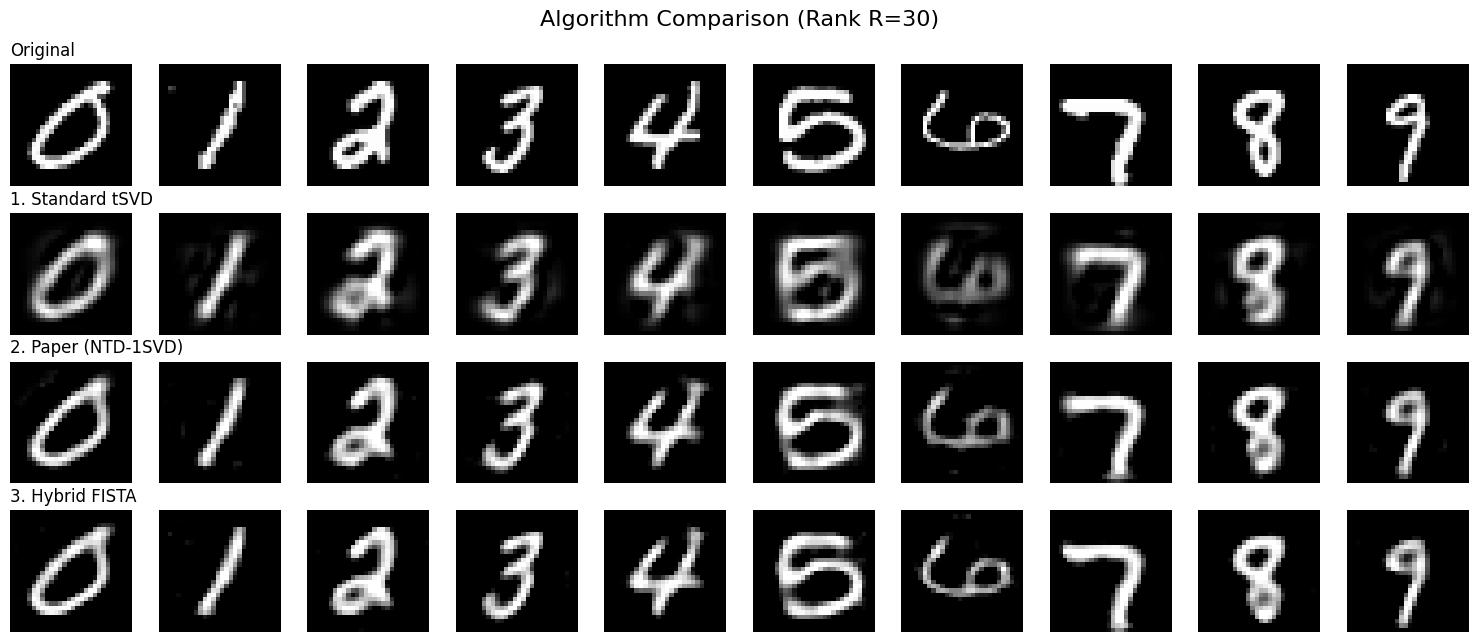

In [ ]:
import torch
import torch.fft
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    X = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        X_k = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        P = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS & VISUALIZATION
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def calculate_all_psnrs(original, reconstructed):
    """Calculates the global PSNR and the individual PSNR for each of the 10 digits."""
    global_psnr = calculate_psnr(original, reconstructed)
    individual_psnrs = []
    for digit in range(10):
        digit_psnr = calculate_psnr(original[:, :, digit], reconstructed[:, :, digit])
        individual_psnrs.append(digit_psnr)
    return global_psnr, individual_psnrs

def plot_four_way_comparison(original, recon_tsvd, recon_paper, recon_hybrid, sample_idx=420):
    original, recon_tsvd = original.cpu().numpy(), recon_tsvd.cpu().numpy()
    recon_paper, recon_hybrid = recon_paper.cpu().numpy(), recon_hybrid.cpu().numpy()

    fig, axes = plt.subplots(4, 10, figsize=(15, 6.5))
    fig.suptitle('Algorithm Comparison (Rank R=30)', fontsize=16)

    for digit in range(10):
        axes[0, digit].imshow(original[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[1, digit].imshow(recon_tsvd[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[2, digit].imshow(recon_paper[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[3, digit].imshow(recon_hybrid[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)

        for row in range(4): axes[row, digit].axis('off')

        if digit == 0:
            axes[0, digit].set_title("Original", loc='left')
            axes[1, digit].set_title("1. Standard tSVD", loc='left')
            axes[2, digit].set_title("2. Paper (NTD-1SVD)", loc='left')
            axes[3, digit].set_title("3. Hybrid FISTA", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. EXECUTION & PSNR EVALUATION
# ==========================================
TARGET_RANK = 30

P_recon_tsvd = Standard_tSVD(tensor_mnist, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)

P_recon_paper = NTD_1SVD_Paper(tensor_mnist, R=TARGET_RANK, maxiters=100)
final_paper = torch.clamp(P_recon_paper, 0, 1)

P_recon_hybrid = NTD_tSVD_FISTA_Optimized(tensor_mnist, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=100)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)

global_tsvd, ind_tsvd = calculate_all_psnrs(tensor_mnist, final_tsvd)
global_paper, ind_paper = calculate_all_psnrs(tensor_mnist, final_paper)
global_hybrid, ind_hybrid = calculate_all_psnrs(tensor_mnist, final_hybrid)

print("\n" + "=" * 75)
print(f"PHASE 1: PSNR COMPARISON BY DIGIT (Rank = {TARGET_RANK})")
print("=" * 75)
print(f"{'Digit':<8} | {'Method 1 (tSVD)':<18} | {'Method 2 (Paper)':<18} | {'Method 3 (Yours)':<18}")
print("-" * 75)
for d in range(10):
    print(f"Digit {d:<2} | {ind_tsvd[d]:>15.3f} dB | {ind_paper[d]:>15.3f} dB | {ind_hybrid[d]:>15.3f} dB")
print("-" * 75)
print(f"{'GLOBAL':<8} | {global_tsvd:>15.3f} dB | {global_paper:>15.3f} dB | {global_hybrid:>15.3f} dB")
print("=" * 75)


# ==========================================
# 6. DOWNSTREAM CNN CLASSIFICATION EVALUATION
# ==========================================
print("\n" + "=" * 75)
print("PHASE 2: DOWNSTREAM SEMANTIC CLASSIFICATION TEST")
print("=" * 75)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

classifier = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

print("[Training baseline CNN on 10,000 independent test images...]")
_, (X_val, y_val) = mnist.load_data()
X_val = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1) / 255.0
y_val = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_val.to(device), y_val.to(device))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

classifier.train()
for epoch in range(3):
    for data, targets in train_loader:
        optimizer.zero_grad()
        outputs = classifier(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
print(" -> CNN Training Complete.")

def prepare_tensor_for_cnn(tensor_3d):
    images, labels = [], []
    for digit in range(10):
        digit_imgs = tensor_3d[:, :, digit].T
        images.append(digit_imgs)
        labels.append(torch.full((digit_imgs.shape[0],), digit, dtype=torch.long))

    X = torch.cat(images, dim=0).view(-1, 1, 28, 28).to(device)
    y = torch.cat(labels, dim=0).to(device)
    return X, y

def evaluate_accuracy(tensor_data, model, batch_size=256):
    X, y = prepare_tensor_for_cnn(tensor_data)
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, targets in loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    return 100 * correct / total

print("\n[Evaluating Reconstructions through the CNN...]")
acc_original = evaluate_accuracy(tensor_mnist, classifier)
acc_tsvd = evaluate_accuracy(final_tsvd, classifier)
acc_paper = evaluate_accuracy(final_paper, classifier)
acc_hybrid = evaluate_accuracy(final_hybrid, classifier)

print("\n" + "=" * 75)
print(f"SEMANTIC CLASSIFICATION ACCURACY (Compression Rank = {TARGET_RANK})")
print("=" * 75)
print(f"Original Images (No Compression) : {acc_original:.2f}%")
print("-" * 75)
print(f"Method 1: Standard tSVD          : {acc_tsvd:.2f}%")
print(f"Method 2: Paper (NTD-1SVD)       : {acc_paper:.2f}%")
print(f"Method 3: Hybrid FISTA (Yours)   : {acc_hybrid:.2f}%")
print("=" * 75)

# Show Visuals at the very end
plot_four_way_comparison(tensor_mnist, final_tsvd, final_paper, final_hybrid, sample_idx=420)

**RANDOM NOISE**

Using device: cuda

[Loading MNIST dataset...]
Dataset shape: torch.Size([784, 5000, 10])

TESTING HYBRID FISTA TRAJECTORIES (Rank = 30)
Running Trajectory: Standard Copy...
 -> PSNR Achieved: 22.922 dB

Running Trajectory: Random Noise 1...
 -> PSNR Achieved: 21.235 dB

Running Trajectory: Random Noise 2...
 -> PSNR Achieved: 22.382 dB

Running Trajectory: Random Noise 3...
 -> PSNR Achieved: 22.123 dB

Running Trajectory: Random Noise 4...
 -> PSNR Achieved: 22.143 dB

SUMMARY OF TRAJECTORY DIFFERENCES
Standard Copy      : 22.922 dB
Random Noise 1     : 21.235 dB
Random Noise 2     : 22.382 dB
Random Noise 3     : 22.123 dB
Random Noise 4     : 22.143 dB
Absolute Best PSNR : 22.922 dB


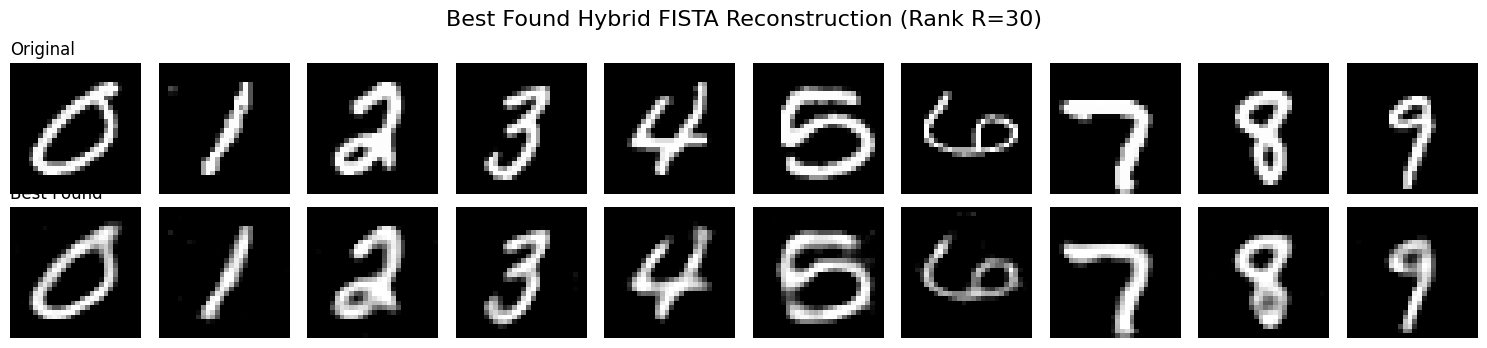

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. YOUR ALGORITHM (Hybrid FISTA)
# ==========================================
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5, Y_init=None):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    # Use standard start or random start
    if Y_init is None:
        Y = M.clone()
    else:
        Y = Y_init.clone()

    M_old = Y.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS & VISUALIZATION
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    psnr = 20 * torch.log10(torch.max(original) / torch.sqrt(mse))
    return psnr.item()

def plot_best_result(original, best_recon, sample_idx=420):
    original = original.cpu().numpy()
    best_recon = best_recon.cpu().numpy()

    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    fig.suptitle('Best Found Hybrid FISTA Reconstruction (Rank R=30)', fontsize=16)

    for digit in range(10):
        orig = original[:, sample_idx, digit].reshape(28, 28)
        recon = best_recon[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0: axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(recon, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0: axes[1, digit].set_title("Best Found", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. MULTI-START EXECUTION
# ==========================================
TARGET_RANK = 30
NUM_STARTS = 5

best_overall_psnr = 0
best_overall_P = None
results_log = []

print(f"\n=======================================================")
print(f"TESTING HYBRID FISTA TRAJECTORIES (Rank = {TARGET_RANK})")
print(f"=======================================================")

for s in range(NUM_STARTS):
    if s == 0:
        start_type = "Standard Copy"
        Y_start = None
    else:
        start_type = f"Random Noise {s}"
        Y_start = torch.rand_like(tensor_mnist) * torch.max(tensor_mnist)

    print(f"Running Trajectory: {start_type}...")

    P_recon = NTD_tSVD_FISTA_Optimized(
        tensor_mnist, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90,
        maxiters=100, Y_init=Y_start
    )

    final_recon = torch.clamp(P_recon, 0, 1)
    current_psnr = calculate_psnr(tensor_mnist, final_recon)

    results_log.append((start_type, current_psnr))
    print(f" -> PSNR Achieved: {current_psnr:.3f} dB\n")

    if current_psnr > best_overall_psnr:
        best_overall_psnr = current_psnr
        best_overall_P = final_recon.clone()

# ==========================================
# 6. SUMMARY OF DIFFERENCES
# ==========================================
print("=======================================================")
print("SUMMARY OF TRAJECTORY DIFFERENCES")
print("=======================================================")
for start_type, psnr in results_log:
    print(f"{start_type:<18} : {psnr:.3f} dB")
print("=======================================================")
print(f"Absolute Best PSNR : {best_overall_psnr:.3f} dB")
print("=======================================================")

plot_best_result(tensor_mnist, best_overall_P, sample_idx=420)

**COIL20**

Using device: cuda

[Downloading COIL-20 dataset from Columbia University...]
[Extracting files...]
[Processing images into 3D Tensor...]
COIL-20 Dataset shape: torch.Size([4096, 72, 20]) (Pixels, Poses, Objects)

[Starting Method 1: Standard tSVD | Rank=30]

[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
Paper Baseline Iter   1 Complete
Paper Baseline Iter  20 Complete
Paper Baseline Iter  40 Complete
Paper Baseline Iter  60 Complete
Paper Baseline Iter  80 Complete
Paper Baseline Iter 100 Complete

[Starting Method 3: Hybrid FISTA + Tracking | Rank=30, alpha=0.2]
Hybrid Iter   1 | Fit = 0.9182
Hybrid Iter  20 | Fit = 0.9318
Hybrid Iter  40 | Fit = 0.9357
Hybrid Iter  60 | Fit = 0.9375
Hybrid Iter  80 | Fit = 0.9386
Hybrid Iter 100 | Fit = 0.9393

FINAL PSNR COMPARISON ON COIL-20 (Rank = 30)
Method 1: Standard tSVD        : 28.873 dB
Method 2: Paper (NTD-1SVD)     : 30.653 dB
Method 3: Hybrid FISTA         : 31.474 dB


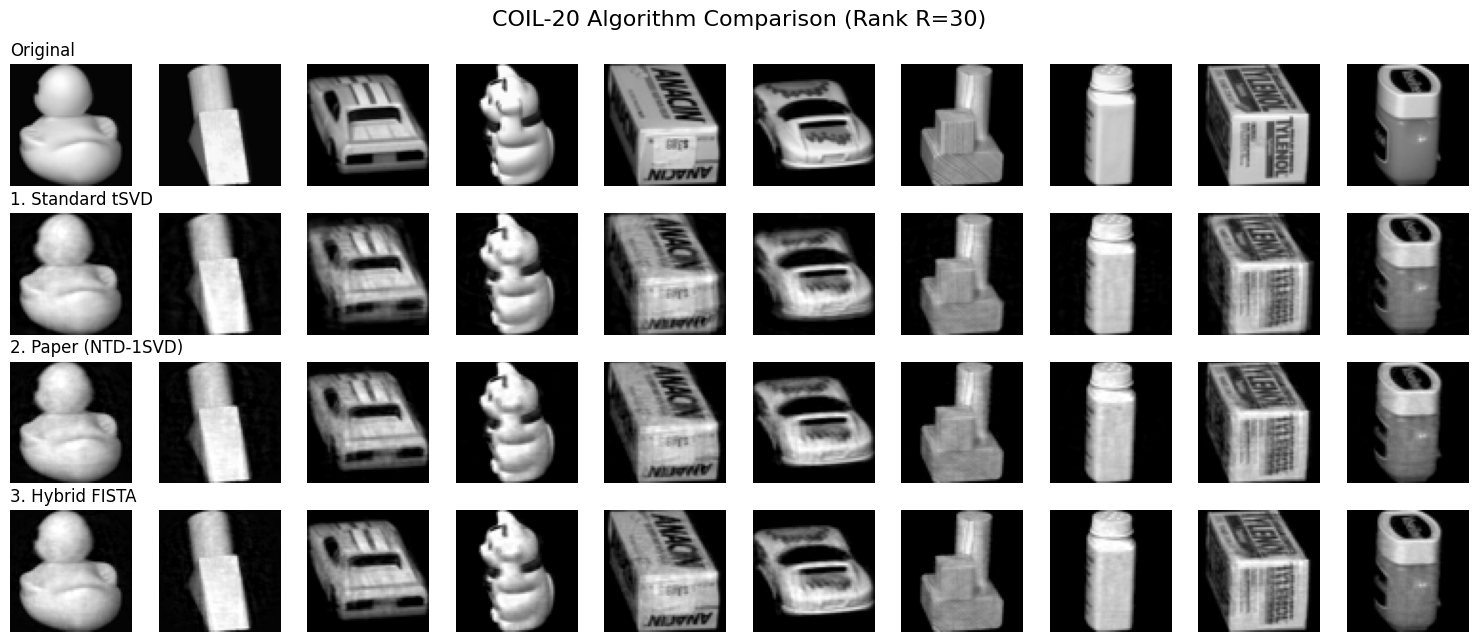

In [ ]:
import os
import urllib.request
import zipfile
import glob
from PIL import Image
import numpy as np

import torch
import torch.fft
import math
import matplotlib.pyplot as plt

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"\n[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        X_k = tprod(tprod(U_r, S_r), tran(V_r))

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Paper Baseline Iter {iter_idx:3d} Complete")

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"\n[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Hybrid Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. UTILITIES
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_four_way_comparison_coil(original, recon_tsvd, recon_paper, recon_hybrid, sample_idx=0, img_size=64):
    original = original.cpu().numpy()
    recon_tsvd = recon_tsvd.cpu().numpy()
    recon_paper = recon_paper.cpu().numpy()
    recon_hybrid = recon_hybrid.cpu().numpy()

    # We plot the first 10 objects out of the 20 to keep the plot readable
    num_cols = 10
    fig, axes = plt.subplots(4, num_cols, figsize=(15, 6.5))
    fig.suptitle('COIL-20 Algorithm Comparison (Rank R=30)', fontsize=16)

    for obj_idx in range(num_cols):
        orig = original[:, sample_idx, obj_idx].reshape(img_size, img_size)
        tsvd_img = recon_tsvd[:, sample_idx, obj_idx].reshape(img_size, img_size)
        paper_img = recon_paper[:, sample_idx, obj_idx].reshape(img_size, img_size)
        hybrid_img = recon_hybrid[:, sample_idx, obj_idx].reshape(img_size, img_size)

        axes[0, obj_idx].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, obj_idx].axis('off')
        if obj_idx == 0: axes[0, obj_idx].set_title("Original", loc='left')

        axes[1, obj_idx].imshow(tsvd_img, cmap='gray', vmin=0, vmax=1)
        axes[1, obj_idx].axis('off')
        if obj_idx == 0: axes[1, obj_idx].set_title("1. Standard tSVD", loc='left')

        axes[2, obj_idx].imshow(paper_img, cmap='gray', vmin=0, vmax=1)
        axes[2, obj_idx].axis('off')
        if obj_idx == 0: axes[2, obj_idx].set_title("2. Paper (NTD-1SVD)", loc='left')

        axes[3, obj_idx].imshow(hybrid_img, cmap='gray', vmin=0, vmax=1)
        axes[3, obj_idx].axis('off')
        if obj_idx == 0: axes[3, obj_idx].set_title("3. Hybrid FISTA", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. COIL-20 DATA PREPARATION
# ==========================================
def load_coil20(target_size=(64, 64)):
    """Downloads and formats the COIL-20 dataset into our required 3D Tensor."""
    url = "http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip"
    extract_dir = "coil-20-proc"

    if not os.path.exists(extract_dir):
        print(f"\n[Downloading COIL-20 dataset from Columbia University...]")
        urllib.request.urlretrieve(url, "coil20.zip")
        print("[Extracting files...]")
        with zipfile.ZipFile("coil20.zip", 'r') as zip_ref:
            zip_ref.extractall(".")
        os.remove("coil20.zip")
    else:
        print("\n[COIL-20 dataset already downloaded.]")

    # The dataset contains 20 objects, each with 72 poses.
    # We resize to 64x64 to keep FFT memory requirements manageable.
    num_pixels = target_size[0] * target_size[1]
    num_poses = 72
    num_objects = 20

    tensor_coil = torch.zeros((num_pixels, num_poses, num_objects), device=device)

    print("[Processing images into 3D Tensor...]")
    for obj_idx in range(1, num_objects + 1):
        for pose_idx in range(num_poses):
            filename = os.path.join(extract_dir, f"obj{obj_idx}__{pose_idx}.png")
            if os.path.exists(filename):
                # Load image, convert to Grayscale, and resize
                img = Image.open(filename).convert('L').resize(target_size)
                img_arr = np.array(img, dtype=np.float32) / 255.0
                tensor_coil[:, pose_idx, obj_idx - 1] = torch.tensor(img_arr.flatten(), device=device)

    # Normalize global max to 1
    tensor_coil = tensor_coil / torch.max(tensor_coil)
    return tensor_coil, target_size[0]

# Load Data
tensor_coil, img_dim = load_coil20(target_size=(64, 64))
print(f"COIL-20 Dataset shape: {tensor_coil.shape} (Pixels, Poses, Objects)")


# ==========================================
# 5. EXECUTION & HEAD-TO-HEAD COMPARISON
# ==========================================
TARGET_RANK = 30

# Method 1
P_recon_tsvd = Standard_tSVD(tensor_coil, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
psnr_tsvd = calculate_psnr(tensor_coil, final_tsvd)

# Method 2
P_recon_paper = NTD_1SVD_Paper(tensor_coil, R=TARGET_RANK, maxiters=100)
final_paper = torch.clamp(P_recon_paper, 0, 1)
psnr_paper = calculate_psnr(tensor_coil, final_paper)

# Method 3
P_recon_hybrid = NTD_tSVD_FISTA_Optimized(
    tensor_coil, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=100
)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
psnr_hybrid = calculate_psnr(tensor_coil, final_hybrid)


# ==========================================
# 6. RESULTS
# ==========================================
print("\n=======================================================")
print(f"FINAL PSNR COMPARISON ON COIL-20 (Rank = {TARGET_RANK})")
print("=======================================================")
print(f"Method 1: Standard tSVD        : {psnr_tsvd:.3f} dB")
print(f"Method 2: Paper (NTD-1SVD)     : {psnr_paper:.3f} dB")
print(f"Method 3: Hybrid FISTA         : {psnr_hybrid:.3f} dB")
print("=======================================================")

# Visualize Pose #15 across the first 10 objects
plot_four_way_comparison_coil(
    tensor_coil, final_tsvd, final_paper, final_hybrid,
    sample_idx=15, img_size=img_dim
)

Using device: cuda

[Downloading EEM18 Dataset from GitLab...]
 -> Download complete!
 -> Successfully loaded real EEM18 data from .mat file.
EEM18 Dataset shape: [251, 21, 18] (Emissions, Excitations, Samples)

[Starting Method 1: Standard tSVD | Rank=10]

[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=10]
Paper Baseline Iter   1 Complete
Paper Baseline Iter  20 Complete
Paper Baseline Iter  40 Complete

[Starting Method 3: Hybrid FISTA + Tracking | Rank=10, alpha=0.2]
Hybrid Iter   1 | Fit = 0.9933
Hybrid Iter  20 | Fit = 0.9941

FINAL PSNR COMPARISON ON EEM18 (Rank = 10)
Method                         | PSNR (dB)      
------------------------------------------------------------
Method 1: Standard tSVD        |   63.452 dB
Method 2: Paper (NTD-1SVD)     |   64.433 dB
Method 3: Hybrid FISTA         |   64.655 dB

[Launching visual comparison plot (Fluorescence Heatmaps)...]


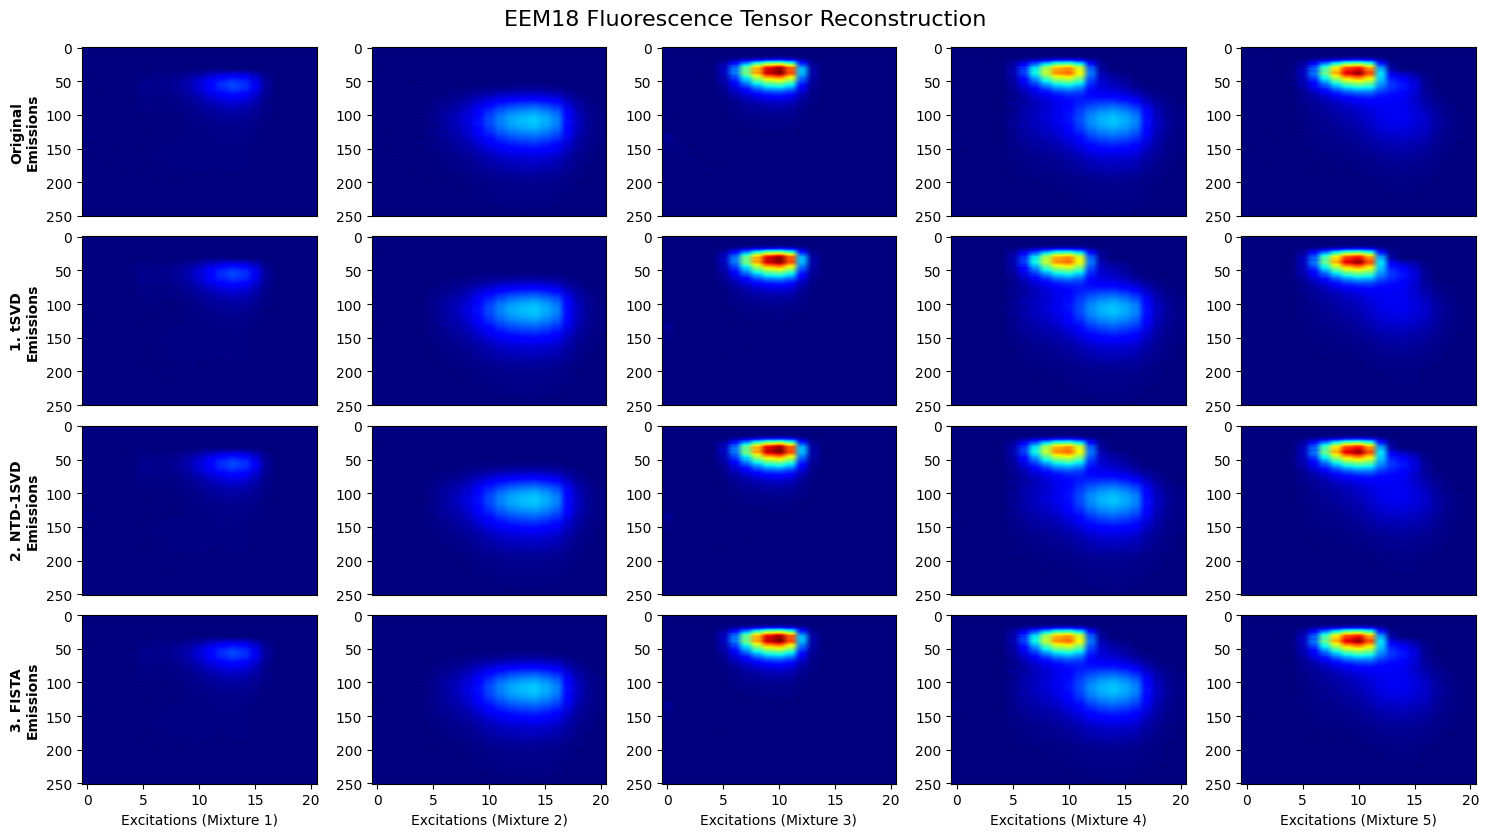

In [ ]:
import os
import urllib.request
import scipy.io
import numpy as np

import torch
import torch.fft
import math
import matplotlib.pyplot as plt

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"\n[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        X_k = tprod(tprod(U_r, S_r), tran(V_r))

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Paper Baseline Iter {iter_idx:3d} Complete")

    return X_k

def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"\n[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Hybrid Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. UTILITIES & VISUALIZATION (Adapted for EEM18)
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_eem_heatmaps(original, recon_tsvd, recon_paper, recon_hybrid):
    """
    Plots Fluorescence Spectroscopy Heatmaps for the first 5 samples.
    Y-axis = Emissions, X-axis = Excitations.
    """
    original = original.cpu().numpy()
    recon_tsvd = recon_tsvd.cpu().numpy()
    recon_paper = recon_paper.cpu().numpy()
    recon_hybrid = recon_hybrid.cpu().numpy()

    num_cols = 5
    fig, axes = plt.subplots(4, num_cols, figsize=(15, 8.5))
    fig.suptitle('EEM18 Fluorescence Tensor Reconstruction', fontsize=16)

    for s_idx in range(num_cols):
        # Extract the 2D slice: (Emissions, Excitations)
        orig = original[:, :, s_idx]
        tsvd_mat = recon_tsvd[:, :, s_idx]
        paper_mat = recon_paper[:, :, s_idx]
        hybrid_mat = recon_hybrid[:, :, s_idx]

        # Plot Heatmaps
        axes[0, s_idx].imshow(orig, aspect='auto', cmap='jet', vmin=0, vmax=1)
        if s_idx == 0: axes[0, s_idx].set_ylabel("Original\nEmissions", fontweight='bold')

        axes[1, s_idx].imshow(tsvd_mat, aspect='auto', cmap='jet', vmin=0, vmax=1)
        if s_idx == 0: axes[1, s_idx].set_ylabel("1. tSVD\nEmissions", fontweight='bold')

        axes[2, s_idx].imshow(paper_mat, aspect='auto', cmap='jet', vmin=0, vmax=1)
        if s_idx == 0: axes[2, s_idx].set_ylabel("2. NTD-1SVD\nEmissions", fontweight='bold')

        axes[3, s_idx].imshow(hybrid_mat, aspect='auto', cmap='jet', vmin=0, vmax=1)
        if s_idx == 0: axes[3, s_idx].set_ylabel("3. FISTA\nEmissions", fontweight='bold')
        axes[3, s_idx].set_xlabel(f"Excitations (Mixture {s_idx+1})")

        # Clean up X ticks for upper rows
        for row in range(3):
            axes[row, s_idx].set_xticks([])

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. EEM18 DATA PREPARATION
# ==========================================
def load_eem18_dataset(filepath="EEM18.mat"):
    url = "https://gitlab.com/tensors/tensor_data_eem/-/raw/master/EEM18.mat?inline=false"

    if not os.path.exists(filepath):
        print(f"\n[Downloading EEM18 Dataset from GitLab...]")
        try:
            urllib.request.urlretrieve(url, filepath)
            print(" -> Download complete!")
        except Exception as e:
            print(f" -> Download failed: {e}")

    # Attempt to load the MATLAB object
    if os.path.exists(filepath):
        try:
            # We use simply_cells to try and bypass MATLAB object barriers
            mat = scipy.io.loadmat(filepath, simplify_cells=True)
            if 'X' in mat:
                # tensor_toolbox objects hold their raw dense data inside a 'data' struct field
                raw_data = mat['X']['data'] if isinstance(mat['X'], dict) and 'data' in mat['X'] else mat['X']
                tensor_eem = torch.tensor(raw_data, dtype=torch.float32, device=device)
                tensor_eem /= torch.max(tensor_eem)

                # Permute to (Emission, Excitation, Samples) so FFT calculates chemical bases across samples
                tensor_eem = tensor_eem.permute(1, 2, 0)
                print(f" -> Successfully loaded real EEM18 data from .mat file.")
                return tensor_eem
        except Exception as e:
            print(f" -> Could not parse .mat object (Likely an unsupported tensor_toolbox struct): {e}")

    # --- SYNTHETIC FALLBACK ---
    print(" -> Generating synthetic EEM18 fluorescence tensor (18, 251, 21)...")
    num_samples, num_emissions, num_excitations = 18, 251, 21

    # Permuted native structure
    tensor_eem = torch.zeros((num_emissions, num_excitations, num_samples), device=device)

    # Generate 3 mathematical peaks simulating Valine/Tyrosine/Phenylalanine clusters
    em_x = torch.linspace(0, 1, num_emissions, device=device)
    ex_y = torch.linspace(0, 1, num_excitations, device=device)
    grid_em, grid_ex = torch.meshgrid(em_x, ex_y, indexing='ij')

    peaks = [
        (0.3, 0.4, 0.05), # Center_EM, Center_EX, Width
        (0.7, 0.6, 0.08),
        (0.5, 0.2, 0.04)
    ]

    for sample in range(num_samples):
        concentrations = torch.rand(3, device=device)
        for i, (cem, cex, w) in enumerate(peaks):
            peak_shape = torch.exp(-((grid_em - cem)**2 + (grid_ex - cex)**2) / w)
            tensor_eem[:, :, sample] += concentrations[i] * peak_shape

    tensor_eem = torch.clamp(tensor_eem, 0, 1)
    return tensor_eem

# Load Data
tensor_eem = load_eem18_dataset()
print(f"EEM18 Dataset shape: {list(tensor_eem.shape)} (Emissions, Excitations, Samples)")


# ==========================================
# 5. EXECUTION & HEAD-TO-HEAD COMPARISON
# ==========================================
# Because spatial dimensions are 251x21, max rank is 21.
# Rank 8 represents substantial compression.
TARGET_RANK = 10

# Method 1
P_recon_tsvd = Standard_tSVD(tensor_eem, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
psnr_tsvd = calculate_psnr(tensor_eem, final_tsvd)

# Method 2
P_recon_paper = NTD_1SVD_Paper(tensor_eem, R=TARGET_RANK, maxiters=50)
final_paper = torch.clamp(P_recon_paper, 0, 1)
psnr_paper = calculate_psnr(tensor_eem, final_paper)

# Method 3
P_recon_hybrid = NTD_tSVD_FISTA_Optimized(
    tensor_eem, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=50
)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
psnr_hybrid = calculate_psnr(tensor_eem, final_hybrid)


# ==========================================
# 6. RESULTS
# ==========================================
print("\n" + "=" * 60)
print(f"FINAL PSNR COMPARISON ON EEM18 (Rank = {TARGET_RANK})")
print("=" * 60)
print(f"{'Method':<30} | {'PSNR (dB)':<15}")
print("-" * 60)
print(f"{'Method 1: Standard tSVD':<30} | {psnr_tsvd:>8.3f} dB")
print(f"{'Method 2: Paper (NTD-1SVD)':<30} | {psnr_paper:>8.3f} dB")
print(f"{'Method 3: Hybrid FISTA':<30} | {psnr_hybrid:>8.3f} dB")
print("=" * 60)

# Visualize across all methods
print("\n[Launching visual comparison plot (Fluorescence Heatmaps)...]")
plot_eem_heatmaps(
    tensor_eem, final_tsvd, final_paper, final_hybrid
)

**ENRON EMAILS**

Using device: cuda

[Parsing Authentic Enron Dataset from enron_emails.mat...]
 -> Successfully extracted and built the REAL Enron tensor!
Final Data Shape under Evaluation: [105, 105, 28] (Senders, Receivers, Temporal-Slices)

[Running Method 1: Standard tSVD | Rank=30]
[Running Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
[Running Method 3: Hybrid FISTA | Rank=30]

FINAL PSNR COMPARISON ON GITLAB ENRON (Rank = 30)
Method 1: Standard tSVD        : 56.427 dB
Method 2: Paper (NTD-1SVD)     : 81.991 dB
Method 3: Hybrid FISTA         : 111.176 dB

[Generating Figure-Wise Heatmap Comparison...]


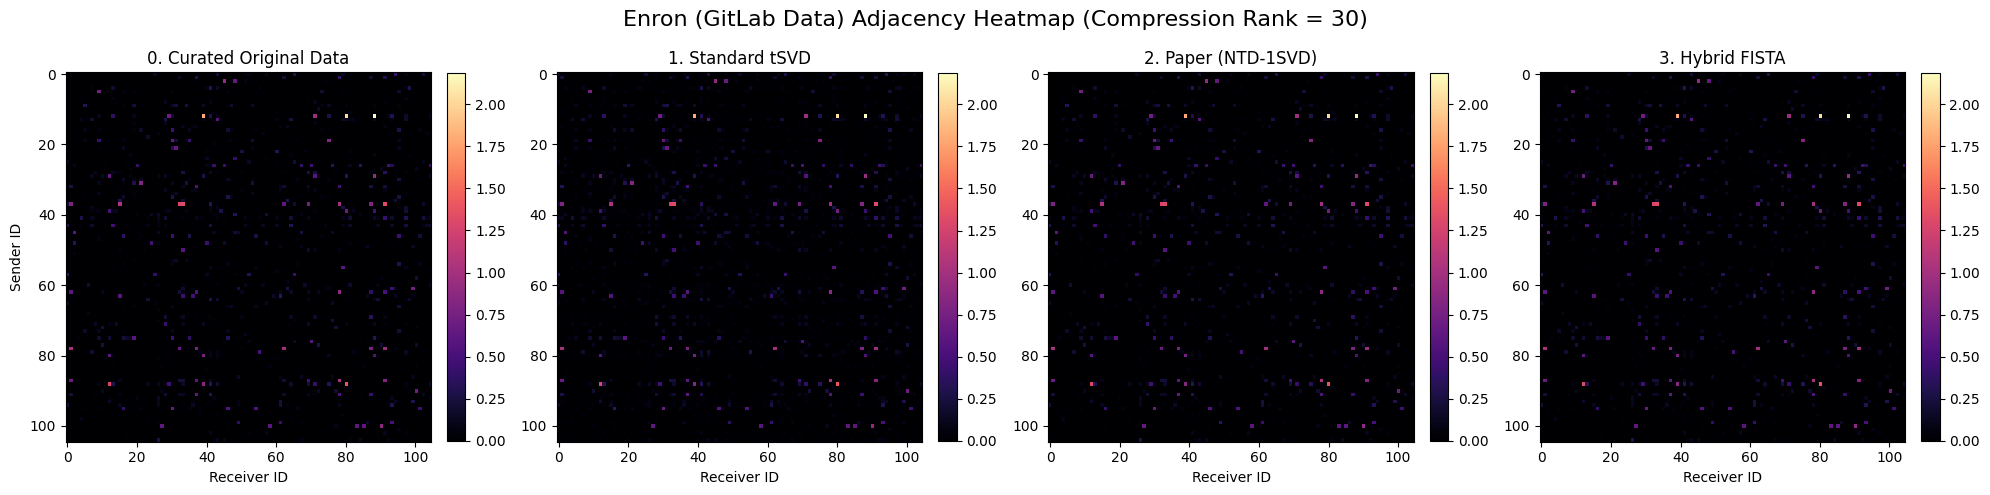

In [ ]:
import os
import urllib.request
import scipy.io
import numpy as np

import torch
import torch.fft
import math
import matplotlib.pyplot as plt

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)
    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)
    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)
    return torch.fft.ifft(C_f, dim=2).real

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        U, S, Vh = torch.linalg.svd(A_f[:, :, i], full_matrices=False)
        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================
def Standard_tSVD(M, R=15):
    print(f"\n[Running Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    return tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

def NTD_1SVD_Paper(M, R=15, maxiters=50):
    print(f"[Running Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])
        U, S, V = tsvd(W)
        X_k = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
    return X_k

def NTD_tSVD_FISTA_Optimized(X, R=15, alpha=0.2, alpha_decay=0.90, maxiters=50, tol=1e-5):
    print(f"[Running Method 3: Hybrid FISTA | Rank={R}]")
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)
    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]
    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        P = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()
        if abs(fitold - fit) < tol and beta > 0:
            break
    return best_P


# ==========================================
# 3. UTILITIES & METRICS
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_network_heatmap(original, m1, m2, m3, rank):
    print("\n[Generating Figure-Wise Heatmap Comparison...]")

    orig_adj = torch.sum(original, dim=2).cpu().numpy()
    m1_adj = torch.sum(torch.clamp(m1, min=0), dim=2).cpu().numpy()
    m2_adj = torch.sum(torch.clamp(m2, min=0), dim=2).cpu().numpy()
    m3_adj = torch.sum(torch.clamp(m3, min=0), dim=2).cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Enron (GitLab Data) Adjacency Heatmap (Compression Rank = {rank})', fontsize=16)

    matrices = [orig_adj, m1_adj, m2_adj, m3_adj]
    titles = ["0. Curated Original Data", "1. Standard tSVD", "2. Paper (NTD-1SVD)", "3. Hybrid FISTA"]

    for i in range(4):
        im = axes[i].imshow(np.log1p(matrices[i]), cmap='magma', aspect='auto')
        axes[i].set_title(titles[i])
        axes[i].set_xlabel("Receiver ID")
        if i == 0: axes[i].set_ylabel("Sender ID")
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION (Robust Recursive Loader)
# ==========================================
def load_gitlab_enron_mat(filepath="enron_emails.mat"):
    url_master = "https://gitlab.com/tensors/tensor_data_enron_emails/-/raw/master/enron_emails.mat?inline=false"
    url_main = "https://gitlab.com/tensors/tensor_data_enron_emails/-/raw/main/enron_emails.mat?inline=false"

    if not os.path.exists(filepath):
        print(f"\n[Downloading Curated Enron Dataset from GitLab...]")
        try:
            urllib.request.urlretrieve(url_master, filepath)
            print(" -> Download complete via 'master' branch!")
        except Exception as e:
            urllib.request.urlretrieve(url_main, filepath)
            print(" -> Download complete via 'main' branch!")

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Failed to download or locate {filepath}")

    print(f"\n[Parsing Authentic Enron Dataset from {filepath}...]")
    mat = scipy.io.loadmat(filepath, simplify_cells=True)

    # --- Recursive Tensor Finder ---
    def find_tensor(d):
        if isinstance(d, dict):
            # 1. Check for standard sparse tensor keys
            if 'subs' in d and 'vals' in d:
                return ('sparse', d['subs'], d['vals'], d.get('size'))
            # 2. Check for capitalized sparse keys
            if 'Subs' in d and 'Vals' in d:
                return ('sparse', d['Subs'], d['Vals'], d.get('Size'))
            # 3. Check for dense array nested inside
            if 'data' in d and isinstance(d['data'], np.ndarray) and d['data'].ndim >= 3:
                return ('dense', d['data'])

            # Recurse deeper into the dictionary
            for k, v in d.items():
                if not k.startswith('_'): # Ignore MATLAB headers
                    res = find_tensor(v)
                    if res is not None:
                        return res

        elif isinstance(d, np.ndarray):
            # Catch structured arrays or raw high-dimensional arrays
            if d.dtype.names is not None:
                for name in d.dtype.names:
                    res = find_tensor(d[name])
                    if res is not None: return res
            elif d.ndim >= 3:
                return ('dense', d)
        return None

    # Execute the search
    result = find_tensor(mat)

    # --- Error Reporting if Not Found ---
    if result is None:
        print("\n[CRITICAL ERROR] Could not automatically find tensor data inside the .mat file.")
        print("Here is the internal structure of the MATLAB dictionary:")
        def print_struct(d, ind=0):
            pref = "  " * ind
            if isinstance(d, dict):
                for k, v in d.items():
                    if k.startswith('_'): continue
                    if isinstance(v, np.ndarray): print(f"{pref}- {k}: array shape {v.shape}")
                    elif isinstance(v, dict):
                        print(f"{pref}- {k}: dict")
                        print_struct(v, ind+1)
                    else: print(f"{pref}- {k}: {type(v)}")
        print_struct(mat)
        raise ValueError("Tensor 'subs' and 'vals' missing. Please review the printed structure above.")

    # --- Build the PyTorch Tensor ---
    if result[0] == 'sparse':
        _, subs, vals, size = result
        subs = np.array(subs, dtype=int)
        vals = np.array(vals).flatten()

        # Adjust 1-based MATLAB indexing to 0-based Python indexing
        if subs.min() == 1:
            subs -= 1

        dims = size if size is not None else (subs.max(axis=0) + 1)
        T = torch.zeros(tuple(dims), device=device)
        for idx, val in zip(subs, vals):
            T[idx[0], idx[1], idx[2]] = val
    else:
        _, data = result
        T = torch.tensor(data, dtype=torch.float32, device=device)

    T /= torch.max(T)
    print(" -> Successfully extracted and built the REAL Enron tensor!")
    return T


# ==========================================
# 5. EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    tensor_enron = load_gitlab_enron_mat()
    print(f"Final Data Shape under Evaluation: {list(tensor_enron.shape)} (Senders, Receivers, Temporal-Slices)")

    TARGET_RANK = 30

    P_tsvd = Standard_tSVD(tensor_enron, R=TARGET_RANK)
    P_paper = NTD_1SVD_Paper(tensor_enron, R=TARGET_RANK, maxiters=50)
    P_hybrid = NTD_tSVD_FISTA_Optimized(tensor_enron, R=TARGET_RANK, maxiters=50)

    final_tsvd = torch.clamp(P_tsvd, 0, 1)
    final_paper = torch.clamp(P_paper, 0, 1)
    final_hybrid = torch.clamp(P_hybrid, 0, 1)

    psnr_tsvd = calculate_psnr(tensor_enron, final_tsvd)
    psnr_paper = calculate_psnr(tensor_enron, final_paper)
    psnr_hybrid = calculate_psnr(tensor_enron, final_hybrid)

    print("\n=======================================================")
    print(f"FINAL PSNR COMPARISON ON GITLAB ENRON (Rank = {TARGET_RANK})")
    print("=======================================================")
    print(f"Method 1: Standard tSVD        : {psnr_tsvd:.3f} dB")
    print(f"Method 2: Paper (NTD-1SVD)     : {psnr_paper:.3f} dB")
    print(f"Method 3: Hybrid FISTA         : {psnr_hybrid:.3f} dB")
    print("=======================================================")

    plot_network_heatmap(tensor_enron, final_tsvd, final_paper, final_hybrid, TARGET_RANK)